## Import Packages

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon
from shapely.geometry import Polygon

In [3]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
# from gridsample.mapping.plot import create_interactive_map

## Set Global Params

### Folder Paths

In [4]:
LOCATION = "Barwani"

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "01 Processed Data"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "02 Outputs" / "v1"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

### Code Parameters

In [6]:
INDIA_PROJECTED_CRS = "24378"

In [7]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

## Custom Functions

In [8]:
def clean_non_polygons(gdf):
    """
    Clean Geometry Collections and MultiPolygons by keeping only Polygons inside
    and dropping points or lines etc.
    """
    def _clean_geom(geom):
        if geom is None:
            return Polygon()
        
        # If it's already a Polygon, return as is
        if geom.geom_type == 'Polygon':
            return geom

        # Get polygons from MultiPolygon or GeometryCollection 
        polygons = []
        if hasattr(geom, 'geoms'):
            for g in geom.geoms:
                if g.geom_type == 'Polygon':
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return Polygon()
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and set invalid geometries to None
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf

In [99]:
def difference_overlay_without_discard(gdf1, gdf2):

    overlay_gdf = gpd.overlay(
        gdf1.reset_index(names="original_index"),
        gdf2,
        how="difference",
        keep_geom_type=False,
    )

    # Create a copy to modify
    gdf1_v2 = gdf1.copy()
    # By default, set all geometries to an empty Polygon
    gdf1_v2["geometry"] = Polygon()
    # Update the geometries for the rows that still exist after the overlay
    gdf1_v2.iloc[overlay_gdf["original_index"]]["geometry"] = overlay_gdf.geometry

    gdf1_v2 = clean_non_polygons(gdf1_v2)

    return gdf1_v2

In [10]:
# for TIFF files
import rasterio
from rasterio.features import shapes
from rasterio.plot import show
from shapely.geometry import shape


def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

## Load cleaned khasras

In [11]:
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
barwani_gdf = gpd.read_parquet(PROCESSED_DATA_DIR / "Cleaned Khasras" / "barwani_cleaned_khasras.parquet")
barwani_gdf

,Khasra ID,Khasra Name,Patch Name,geometry
0,BWI1004_khasra_121/1_part_1,121/1,BWI1004,"POLYGON ((74.94467 21.72595, 74.94464 21.72608..."
1,BWI1004_khasra_121/1_part_2,121/1,BWI1004,"POLYGON ((74.94475 21.72560, 74.94469 21.72559..."
2,BWI1004_khasra_121/2,121/2,BWI1004,"POLYGON ((74.94475 21.72560, 74.94471 21.72577..."
3,BWI1004_khasra_122,122,BWI1004,"POLYGON ((74.94874 21.72558, 74.94874 21.72568..."
4,BWI1004_khasra_123_part_1,123,BWI1004,"POLYGON ((74.94874 21.72558, 74.94866 21.72557..."
...,...,...,...,...
15736,BWI99_khasra_56,56,BWI99,"POLYGON ((75.12132 21.46965, 75.12127 21.46964..."
15737,BWI99_khasra_57,57,BWI99,"POLYGON ((75.11914 21.46930, 75.11909 21.46916..."
15738,BWI99_khasra_91,91,BWI99,"POLYGON ((75.12096 21.46753, 75.12084 21.46760..."
15739,BWI99_khasra_96,96,BWI99,"POLYGON ((75.12230 21.46923, 75.12220 21.46923..."


In [13]:
gdf_4326 = barwani_gdf
gdf = barwani_gdf.to_crs(INDIA_PROJECTED_CRS)

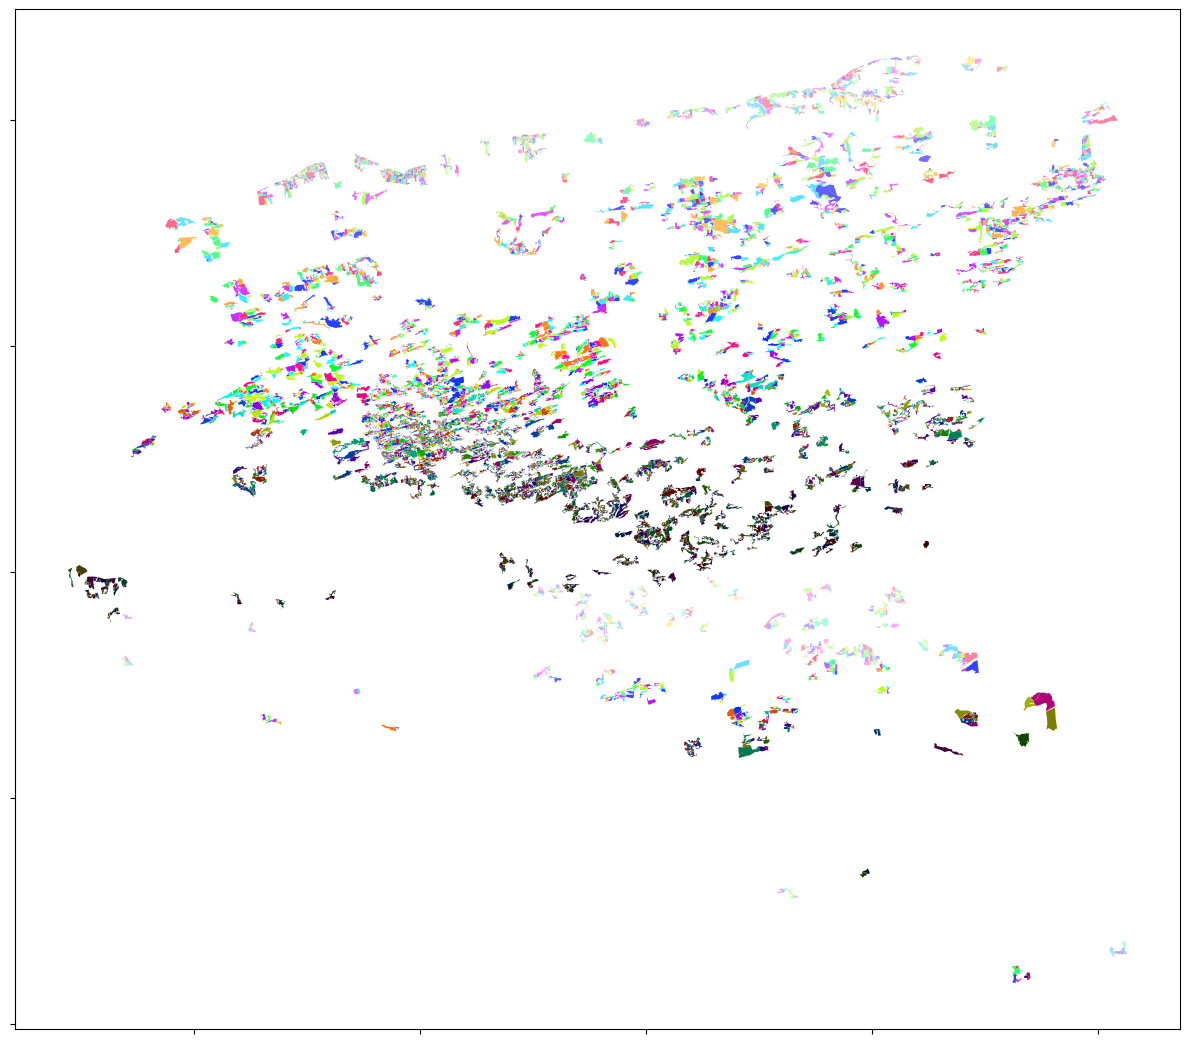

In [14]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [15]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [16]:
from gridsample.utils_rooftop import (
    download_VIDA_rooftops_data_by_s2,
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
)

#### Identify S2 cell IDs

In [17]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 4
Unique S2 cell IDs: [4314166968044224512, 4312478118183960576, 4134585932902825984, 4135148882856247296]


#### Check if identified cells cover all areas of interest


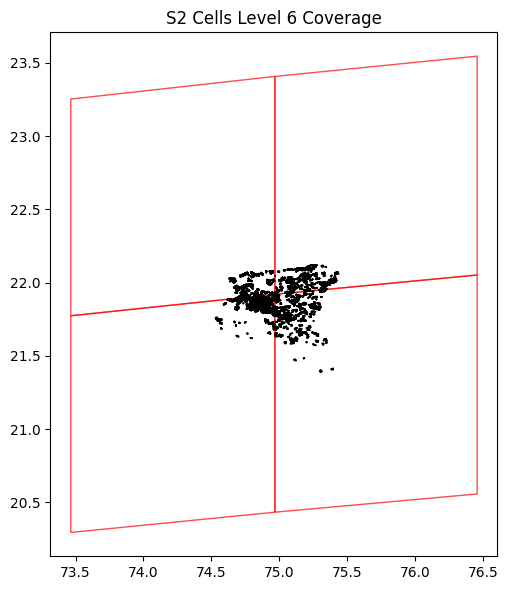

0.0 square degrees area not covered by an S2 cell


In [18]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [19]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

File 4314166968044224512 already exists.
File 4312478118183960576 already exists.
File 4134585932902825984 already exists.
File 4135148882856247296 already exists.


#### Load and process rooftop data

In [20]:
try:
    print("Checking for existing filtered rooftops...")
    subset_rooftops_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Rooftops" / "rooftops.parquet"
    )
    print("Loaded existing filtered rooftops.")
except FileNotFoundError:
    print("No saved filtered rooftops found, processing raw data...")
    rooftop_gdf_list = []
    for s2_cell_id in s2_cell_ids:
        s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
        rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
        rooftop_gdf_list.append(rooftop_gdf)

    rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
    rooftop_gdf = rooftop_gdf[
        [
            "bf_source",
            "confidence",
            "area_in_meters",
            "geometry",
        ]
    ]

    rooftop_gdf["rooftop_id"] = create_ids(
        len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_"
    )
    rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

    # Filter to only rooftops that overlap the parcels
    subset_rooftops_gdf = rooftop_gdf.sjoin(
        gdf, how="inner", predicate="intersects"
    ).drop(columns=["index_right"])
    subset_rooftops_gdf.drop(columns=gdf.columns.drop("geometry"), inplace=True)

    save_shapefiles(
        subset_rooftops_gdf,
        PROCESSED_DATA_DIR / "Filtered Rooftops",
        "rooftops",
        formats=["parquet"],
    )

Checking for existing filtered rooftops...
Loaded existing filtered rooftops.


In [21]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, gdf, how="intersection"
)

#### Settlements

In [22]:
from sklearn.cluster import DBSCAN

Try different thresholds

In [23]:
# for eps in [200, 250, 300]:
#     clusterer = DBSCAN(eps=eps, min_samples=3, n_jobs=-1)
#     building_centroids = buildings_overlap_gdf.geometry.centroid
#     X = np.array(list(zip(building_centroids.x, building_centroids.y)))
#     building_cluster_ids = clusterer.fit_predict(X)
#     buildings_overlap_gdf["settlement_id"] = building_cluster_ids

#     settlement_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] != -1
#     ]
#     rogue_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] == -1
#     ]

#     # get the convex hull of each cluster
#     settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
#     settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
#     settlements_gdf.geometry = settlements_gdf.convex_hull

#     # get cutout of the buffered building shapes that overlap parcels
#     settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
#     settlements_gdf = settlements_gdf[["Khasra Name", "settlement_id", "geometry"]]

#     # plot
#     ax = gdf.plot(figsize=(20, 20))
#     settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
#     settlement_buildings_gdf.plot(ax=ax, color="red")
#     rogue_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

#     # add stats
#     total_count = len(buildings_overlap_gdf)
#     settlement_count = len(settlement_buildings_gdf)
#     perc_settlement_buildings = settlement_count / total_count * 100
#     rogue_count = len(rogue_buildings_gdf)
#     total_area = buildings_overlap_gdf.area.sum() / 10_000
#     settlement_area = settlements_gdf.area.sum() / 10_000
#     title = f"""
#     Buildings at {eps}m eps
#     Total Buildings: {total_count}
#     Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
#     Total Building Area (ha): {total_area:.2f}
#     Settlement Area (ha): {settlement_area:.2f}
#     """
#     ax.set_title(title, fontsize=12)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     plt.savefig(
#         DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
#     )

Run for the chosen threshold

In [24]:
CHOSEN_EPS = 250
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=3, n_jobs=-1)

building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)

buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID", "settlement_id", "geometry"]]

In [25]:
building_counts_df = buildings_overlap_gdf.groupby("Khasra ID").size().reset_index(name="Building Count")
building_counts_df

,Khasra ID,Building Count
0,BWI1004_khasra_122,10
1,BWI1004_khasra_123_part_1,3
2,BWI1004_khasra_124_part_2,8
3,BWI1004_khasra_125,1
4,BWI1004_khasra_22,9
...,...,...
5658,BWI99_khasra_20,12
5659,BWI99_khasra_25,5
5660,BWI99_khasra_56,5
5661,BWI99_khasra_57,6


In [26]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(by="Khasra ID").reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(by="Khasra ID").reset_index()

In [27]:
rogue_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = rogue_buildings_overlap_gdf.area / 10_000
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[["Khasra ID", "Unavailable Area - Isolated Buildings (ha)"]]

In [28]:
settlements_overlap_gdf = settlements_gdf.dissolve(by="Khasra ID").reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = settlements_overlap_gdf.area / 10_000
settlements_unusable_area_df = settlements_overlap_gdf[["Khasra ID", "Unusable Area - Settlements (ha)"]]

### Landcover (Cropland, Water)

#### Landcover

In [29]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

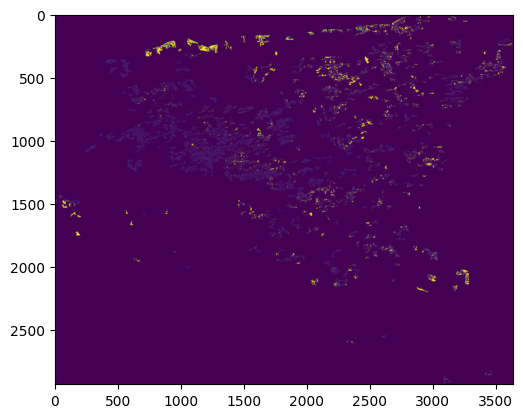

<Axes: >

In [30]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [gdf_4326.unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [31]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [32]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [33]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="Khasra ID").reset_index()

In [34]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["Khasra ID", "Unavailable Area - Cropland (ha)"]]

#### Water

In [35]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [36]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_shapes_gdf, gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID").reset_index()

In [37]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["Khasra ID", "Unusable Area - Water (ha)"]]

#### Trees (not used right now)

In [38]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [39]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(
    tree_shapes_gdf, gdf, how="intersection"
)
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID").reset_index()

In [40]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[["Khasra ID", "Unusable Area - Tree Cover (ha)"]]
tree_unusable_area_df

,Khasra ID,Unusable Area - Tree Cover (ha)
0,BWI1115_khasra_56/1,0.052613
1,BWI1301_khasra_252,0.052637
2,BWI1417_khasra_23,0.073851
3,BWI1441_khasra_640,0.051439
4,BWI1743_khasra_302,0.568640
...,...,...
101,BWI4553_khasra_144,1.520314
102,BWI4556_khasra_146_part_2,0.416176
103,BWI4556_khasra_146_part_3,0.025041
104,BWI4556_khasra_2_part_2,0.121667


### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [41]:
from utils import get_steep_shapes

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pydem/dem_processing.py:76: RuntimeWarning: Cython functions are not compiled. UCA cannot be calculated. Consider compiling cython functions using: python setup.py build_ext --inplace
  warnings.warn("Cython functions are not compiled. UCA cannot be calculated."


In [42]:
# input the bounds below in the website and download all tiles that overlap it
gdf_4326.total_bounds

array([74.52937788, 21.38924295, 75.43785863, 22.12235078])

In [43]:
try:
    print("Checking for existing slope overlaps...")
    slope_overlap_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / "slopes.parquet"
    )
except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")
    dem_filenames = [
        "P5_PAN_CD_N21_000_E074_000_DEM_30m",
        "P5_PAN_CD_N21_000_E075_000_DEM_30m",
        "P5_PAN_CD_N22_000_E074_000_DEM_30m",
        "P5_PAN_CD_N22_000_E075_000_DEM_30m",
    ]

    steep_shapes_gdf_list = []
    for dem_filename in dem_filenames:
        dem_folderpath = RAW_DATA_DIR / "elevation"
        steep_shapes_gdf = get_steep_shapes(
            dem_folderpath=dem_folderpath,
            dem_filename=dem_filename,
            projected_crs=INDIA_PROJECTED_CRS,
            plot=False,
        )
        steep_shapes_gdf_list.append(steep_shapes_gdf)

    slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

    slope_overlap_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_gdf = slope_overlap_gdf.dissolve(by="Khasra ID").reset_index()

    save_shapefiles(
        slope_overlap_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        "slopes",
        formats=["parquet"],
    )

Checking for existing slope overlaps...


<Axes: >

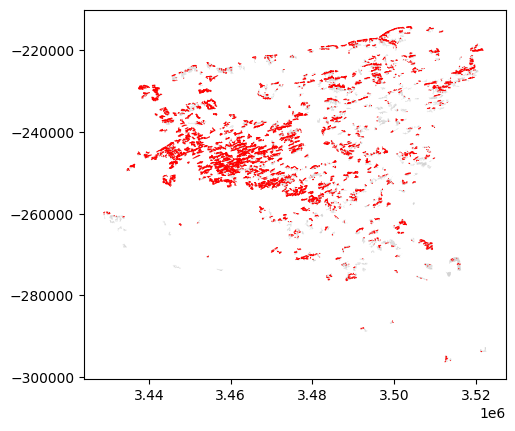

In [44]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

In [45]:
slope_overlap_gdf["Unavailable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["Khasra ID", "Unavailable Area - Slope (ha)"]]

## Save individual layers to file

In [46]:
output_khasra_gdf_v0 = gdf.copy()
selected_Name_list = output_khasra_gdf_v0["Khasra ID"].unique()

In [47]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# rogue buildings
save_shapefiles(
    rogue_buildings_overlap_gdf.loc[
        rogue_buildings_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "rogue_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["Khasra ID"].isin(selected_Name_list),
        [
            "Khasra ID",
            "geometry",
            "Unavailable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

## Merge in unusable layers

### Plots

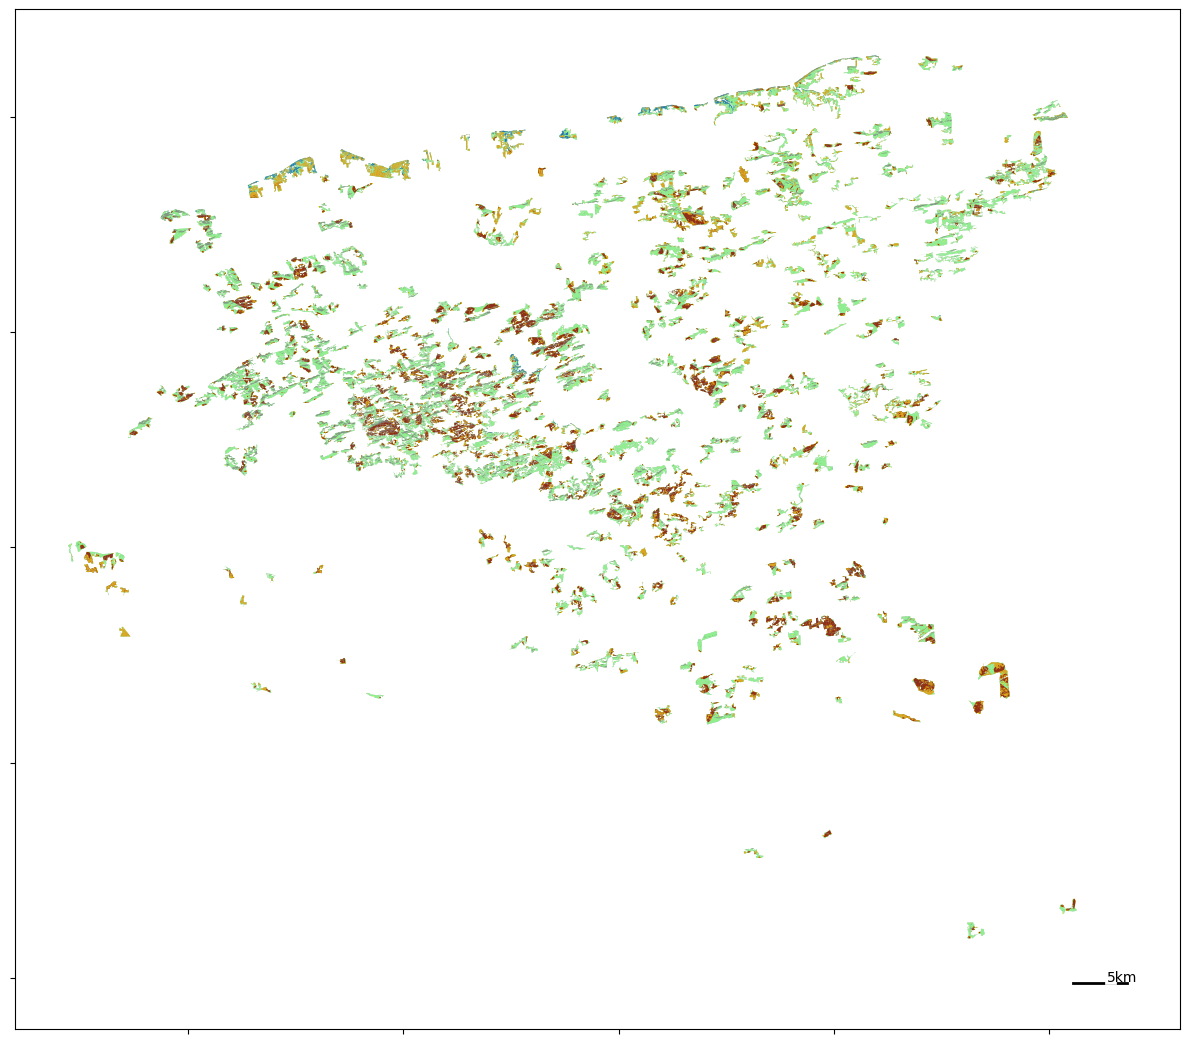

In [48]:
# add colored outline based on Name

ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
output_khasra_gdf_v0.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["Khasra ID"].isin(selected_Name_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["Khasra ID"].isin(selected_Name_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")

water_overlap_gdf[water_overlap_gdf["Khasra ID"].isin(selected_Name_list)].plot(
    ax=ax, color=WATER_COLOR, label="Water"
)

cropland_overlap_gdf[
    cropland_overlap_gdf["Khasra ID"].isin(selected_Name_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

slope_overlap_gdf[slope_overlap_gdf["Khasra ID"].isin(selected_Name_list)].plot(
    ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg"
)

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

### Calculate Areas

##### Cut out unusable

In [108]:
output_khasra_gdf_v0["Original Area (ha)"] = output_khasra_gdf_v0["geometry"].area / 10_000

In [109]:
output_khasra_gdf = output_khasra_gdf_v0.copy()

In [110]:
# cut out water
output_khasra_gdf = difference_overlay_without_discard(
    output_khasra_gdf,
    water_overlap_gdf,
)

# cut out settlements
output_khasra_gdf = difference_overlay_without_discard(
    output_khasra_gdf,
    settlements_overlap_gdf,
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [111]:
# make usable area var so we can put unusable columns first, then usable ones
usable_area_series = output_khasra_gdf.area / 10_000
# unusable area
output_khasra_gdf["Unusable Area (ha)"] = (
    output_khasra_gdf["Original Area (ha)"] - usable_area_series
)
# usable area
output_khasra_gdf["Usable Area (ha)"] = usable_area_series

In [112]:
save_shapefiles(
    output_khasra_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1019: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 0]),  # minx
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1020: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 1]),  # miny
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1021: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 2]),  # maxx
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1022: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 3]),  # maxy


##### Cut out unavailable

In [113]:
# cut out cropland
output_khasra_gdf = difference_overlay_without_discard(
    output_khasra_gdf,
    cropland_overlap_gdf,
)

# cut out rogue buildings
output_khasra_gdf = difference_overlay_without_discard(
    output_khasra_gdf,
    rogue_buildings_overlap_gdf,
)

# cut out slopes
output_khasra_gdf = difference_overlay_without_discard(
    output_khasra_gdf,
    slope_overlap_gdf,
)

In [114]:
output_khasra_gdf["Usable and Available Area (ha)"] = output_khasra_gdf.area / 10_000
output_khasra_gdf["Usable but Unavailable Area (ha)"] = (
    output_khasra_gdf["Usable Area (ha)"]
    - output_khasra_gdf["Usable and Available Area (ha)"]
)

In [115]:
# percentages
output_khasra_gdf["Unusable Area (%)"] = (
    output_khasra_gdf["Unusable Area (ha)"]
    / output_khasra_gdf["Original Area (ha)"]
    * 100
)
output_khasra_gdf["Usable Area (%)"] = (
    output_khasra_gdf["Usable Area (ha)"]
    / output_khasra_gdf["Original Area (ha)"]
    * 100
)
output_khasra_gdf["Usable and Available Area (%)"] = (
    output_khasra_gdf["Usable and Available Area (ha)"]
    / output_khasra_gdf["Original Area (ha)"]
    * 100
)
output_khasra_gdf["Usable but Unavailable Area (%)"] = (
    output_khasra_gdf["Usable but Unavailable Area (ha)"]
    / output_khasra_gdf["Original Area (ha)"]
    * 100
)

In [116]:
# compile all unusable area columns
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="Khasra ID", how="outer")
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="Khasra ID", how="outer")
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="Khasra ID", how="outer")
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="Khasra ID", how="outer")
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(building_counts_df, on="Khasra ID", how="outer")

# add onto the output and fill in null values with zeros (layer cols that don't overlap a given khasra will have null)
output_khasra_gdf = output_khasra_gdf.merge(all_unusable_area_cols_df, on="Khasra ID", how="left")
output_khasra_gdf = output_khasra_gdf.fillna(0)

In [117]:
save_shapefiles(
    output_khasra_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1019: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 0]),  # minx
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1020: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 1]),  # miny
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1021: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 2]),  # maxx
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/array.py:1022: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 3]),  # maxy


### Save per-patch statistics

In [118]:
patch_level_stats_df = (
    output_khasra_gdf.drop(
        columns=[
            "Khasra Name",
            "Khasra ID",
            "Unusable Area (%)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "geometry",
        ]
    )
    .groupby("Patch Name")
    .sum()
)
# make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
count_filtered_parcel_gdf = output_khasra_gdf.groupby("Patch Name").agg(
    khasra_count=("Khasra ID", "size"),
    khasra_names=("Khasra ID", lambda x: ", ".join(list(x))),
)
count_filtered_parcel_gdf.rename(
    columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra IDs"},
    inplace=True,
)
# combine
patch_level_stats_df = patch_level_stats_df.merge(
    count_filtered_parcel_gdf, on="Patch Name"
)

In [119]:
# calculate % columns again

patch_level_stats_df["Unusable Area (%)"] = (
    patch_level_stats_df["Unusable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable Area (%)"] = (
    patch_level_stats_df["Usable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable and Available Area (%)"] = (
    patch_level_stats_df["Usable and Available Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable but Unavailable Area (%)"] = (
    patch_level_stats_df["Usable but Unavailable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)

In [120]:
patch_level_stats_df = patch_level_stats_df[
    [
        "Original Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "Khasra Count",
        "Khasra IDs",
    ]
]

In [121]:
patch_level_stats_df

,Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),Usable but Unavailable Area (ha),Unusable Area (%),Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,Khasra Count,Khasra IDs
Patch Name,,,,,,,,,,,,,,,,,
BWI1004,53.734817,53.734817,0.0,0.0,0.0,100.0,0.0,0.0,0.0,10.483838,0.000000,0.0,2.166327,5.571507,59.0,51,"BWI1004_khasra_121/1_part_1, BWI1004_khasra_12..."
BWI1019,32.191839,32.191839,0.0,0.0,0.0,100.0,0.0,0.0,0.0,8.899144,0.000000,0.0,1.017946,1.809152,40.0,18,"BWI1019_khasra_155, BWI1019_khasra_159, BWI101..."
BWI1035,23.221515,23.221515,0.0,0.0,0.0,100.0,0.0,0.0,0.0,1.181147,0.000000,0.0,0.000000,1.745636,11.0,7,"BWI1035_khasra_117, BWI1035_khasra_121, BWI103..."
BWI1044,30.305211,30.305211,0.0,0.0,0.0,100.0,0.0,0.0,0.0,12.538069,0.000000,0.0,26.769752,0.000000,25.0,1,BWI1044_khasra_403
BWI1051,34.342316,34.342316,0.0,0.0,0.0,100.0,0.0,0.0,0.0,21.955978,0.000000,0.0,29.504909,0.000000,154.0,23,"BWI1051_khasra_170, BWI1051_khasra_191/1, BWI1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BWI972,24.502883,24.502883,0.0,0.0,0.0,100.0,0.0,0.0,0.0,10.413579,0.000000,0.0,3.852335,0.998588,47.0,7,"BWI972_khasra_179, BWI972_khasra_181, BWI972_k..."
BWI984,21.204966,21.204966,0.0,0.0,0.0,100.0,0.0,0.0,0.0,11.791905,0.000000,0.0,19.237790,0.000000,26.0,17,"BWI984_khasra_108, BWI984_khasra_109, BWI984_k..."
BWI989,42.729055,42.729055,0.0,0.0,0.0,100.0,0.0,0.0,0.0,8.201412,0.025735,0.0,9.482280,2.104027,49.0,8,"BWI989_khasra_246, BWI989_khasra_248/1, BWI989..."


In [122]:
patch_level_stats_df.to_csv(
    OUTPUT_DATA_DIR / "patch_stats.csv"
)

## Cluster and get stats